## 1. Imports and config

In [2]:
import os
import time
import pickle

import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [3]:
IMG_SIZE = (32, 32)            # resize target
DATA_DIR = "dataset"           # root folder with one subfolder per class
CLASS_NAMES = ["speed_limit", "stop", "yield"]
MODEL_PATH = "sign_classifier.pkl"
RANDOM_STATE = 42
BATCH_SIZE = 32
EPOCHS = 25

## 2. Preprocessing functions

In [4]:
def preprocess_image(img_path, size=IMG_SIZE):
    """Load an image, resize it, convert to grayscale, and normalize to [0, 1]."""
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    img = cv2.resize(img, size)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    normalized = gray.astype("float32") / 255.0
    return normalized.reshape(size[0], size[1], 1)

In [5]:
def load_dataset(data_dir=DATA_DIR, class_names=CLASS_NAMES):
    """Walk the dataset folder and build (X, y) arrays from every image."""
    X, y = [], []

    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_dir):
            raise FileNotFoundError(f"Expected folder not found: {class_dir}")

        for fname in os.listdir(class_dir):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg", ".ppm")):
                continue
            fpath = os.path.join(class_dir, fname)
            try:
                X.append(preprocess_image(fpath))
                y.append(label_idx)
            except ValueError as e:
                print(f"Skipping unreadable file: {e}")

    X = np.array(X, dtype="float32")
    y = np.array(y, dtype="int32")
    print(f"Loaded {len(X)} images across {len(class_names)} classes.")
    return X, y

## 3. Load and split the data\nThis is the first cell where you'll see real output — it should print how many images were found in each class.

In [6]:
X, y = load_dataset()
y_cat = to_categorical(y, num_classes=len(CLASS_NAMES))

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_cat, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)}  Val: {len(X_val)}  Test: {len(X_test)}")

Loaded 450 images across 3 classes.
Train: 315  Val: 67  Test: 68


## 4. Build the CNN

In [7]:
def build_model(input_shape=(32, 32, 1), num_classes=3):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(16, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = build_model(input_shape=X_train.shape[1:], num_classes=len(CLASS_NAMES))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 16)          │             160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 152,771 (596.76 KB)

 Trainable params: 152,771 (596.76 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Train\nThis cell will print progress per epoch, same as running it from the terminal.

In [8]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4, restore_best_weights=True
)

# Light augmentation to compensate for the dataset's clean, centered crops
augmenter = ImageDataGenerator(
    rotation_range=10,
    brightness_range=(0.8, 1.2),
)
train_flow = augmenter.flow(X_train, y_train, batch_size=BATCH_SIZE)

history = model.fit(
    train_flow,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=[early_stop],
)

Epoch 1/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.4413 - loss: 0.9823 - val_accuracy: 1.0000 - val_loss: 0.4743
Epoch 2/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4857 - loss: 0.8426 - val_accuracy: 1.0000 - val_loss: 0.1426
Epoch 3/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4730 - loss: 0.8268 - val_accuracy: 1.0000 - val_loss: 0.1005
Epoch 4/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4825 - loss: 0.8486 - val_accuracy: 1.0000 - val_loss: 0.0269
Epoch 5/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4952 - loss: 0.8240 - val_accuracy: 1.0000 - val_loss: 0.0193
Epoch 6/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4825 - loss: 0.8687 - val_accuracy: 1.0000 - val_loss: 0.0187
Epoch 7/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5079 - loss: 0.8295 - val_accuracy: 1.0000 - val_loss: 0.0190
Epoch 8/25
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4825 - loss: 0.8306 - val_accuracy: 1.0000 - v

Optional: plot training curves to see how accuracy/loss evolved.

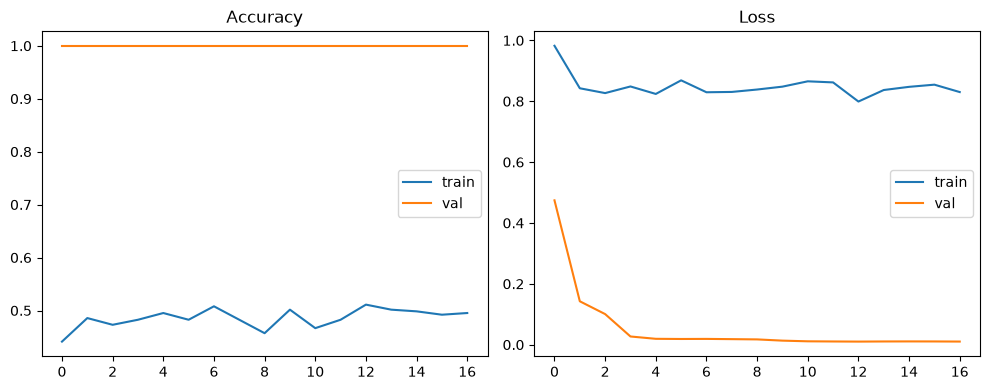

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Evaluate on the held-out test set

In [10]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

print("Classification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

print("Confusion matrix:")
print(confusion_matrix(y_true, y_pred))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Classification report:
              precision    recall  f1-score   support

 speed_limit       1.00      1.00      1.00        29
        stop       1.00      1.00      1.00        20
       yield       1.00      1.00      1.00        19

    accuracy                           1.00        68
   macro avg       1.00      1.00      1.00        68
weighted avg       1.00      1.00      1.00        68

Confusion matrix:
[[29  0  0]
 [ 0 20  0]
 [ 0  0 19]]


## 7. Save and reload the model with Pickle

In [11]:
with open(MODEL_PATH, "wb") as f:
    pickle.dump(model, f)
print(f"Model pickled to {MODEL_PATH}")

with open(MODEL_PATH, "rb") as f:
    loaded_model = pickle.load(f)
print(f"Model loaded from {MODEL_PATH}")

Model pickled to sign_classifier.pkl
Model loaded from sign_classifier.pkl


## 8. Simulated real-time inference\nLoops over a few sample images as if they were incoming camera frames, timing each prediction.

In [12]:
def classify_frame(model, img_path, class_names=CLASS_NAMES):
    processed = preprocess_image(img_path)
    processed = np.expand_dims(processed, axis=0)  # add batch dimension

    start = time.time()
    prediction = model.predict(processed, verbose=0)
    latency_ms = (time.time() - start) * 1000

    label = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction))
    return label, confidence, latency_ms

sample_dir = os.path.join(DATA_DIR, CLASS_NAMES[0])
sample_images = [
    os.path.join(sample_dir, f)
    for f in os.listdir(sample_dir)[:5]
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".ppm"))
]

latencies = []
for img_path in sample_images:
    label, confidence, latency_ms = classify_frame(loaded_model, img_path)
    latencies.append(latency_ms)
    print(f"{os.path.basename(img_path):20s} -> {label:12s} "
          f"(confidence: {confidence:.2f}, {latency_ms:.1f} ms)")

if latencies:
    print(f"\nAverage inference latency: {np.mean(latencies):.1f} ms/frame")

speed_limit_000.png  -> speed_limit  (confidence: 0.99, 109.5 ms)
speed_limit_001.png  -> speed_limit  (confidence: 0.98, 66.2 ms)
speed_limit_002.png  -> speed_limit  (confidence: 0.99, 67.4 ms)
speed_limit_003.png  -> speed_limit  (confidence: 0.99, 67.7 ms)
speed_limit_004.png  -> speed_limit  (confidence: 0.99, 69.8 ms)

Average inference latency: 76.1 ms/frame
